# 0. Импорт необходимых библиотек

In [19]:
# Импортируем нужные библиотеки

from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt

import warnings
 
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

import pysindy as ps
from pysindy.differentiation import SmoothedFiniteDifference
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split # класс разбиения на данные для обучения и для проверки
from sklearn.preprocessing import MinMaxScaler


# 1. Базовая задача с ОДУ Лоренца. Генерация искусстревнного массива данных.

In [20]:
# 1.1. Истинная система Лоренца (для генерации данных)
def lorenz_ode(t, state, sigma=10.0, rho=28.0, beta=8/3):
    """
    Правая часть системы обыкновенных дифференциальных уравнений Лоренца.
       
    Параметры:
    ----------
    state : array-like of shape (3,)
            Вектор текущего состояния системы: [x, y, z].
    sigma : float, optional
            Число Прандтля (отношение вязкости к температуропроводности). 
            Классическое значение: 10.0.
    rho : float, optional
            Нормированное число Рэлея (характеризует разность температур). 
            При rho=28 система переходит в хаотический режим.
    beta : float, optional
            Геометрический параметр конвективной ячейки. Классическое значение: 8/3 (~2.667).
        
    Возвращает:
    ----------
    list[float]
        Вектор производных состояния: [dx/dt, dy/dt, dz/dt].
        
    Примечание:
    -----------
    При параметрах (sigma=10, rho=28, beta=8/3) система формирует 
    «странный аттрактор Лоренца» и демонстрирует детерминированный хаос.
    """
    x, y, z = state

    x_dot = sigma * (y - x)
    y_dot = x * (rho - z) - y
    z_dot = x * y - beta * z

   
    return [x_dot, y_dot, z_dot]

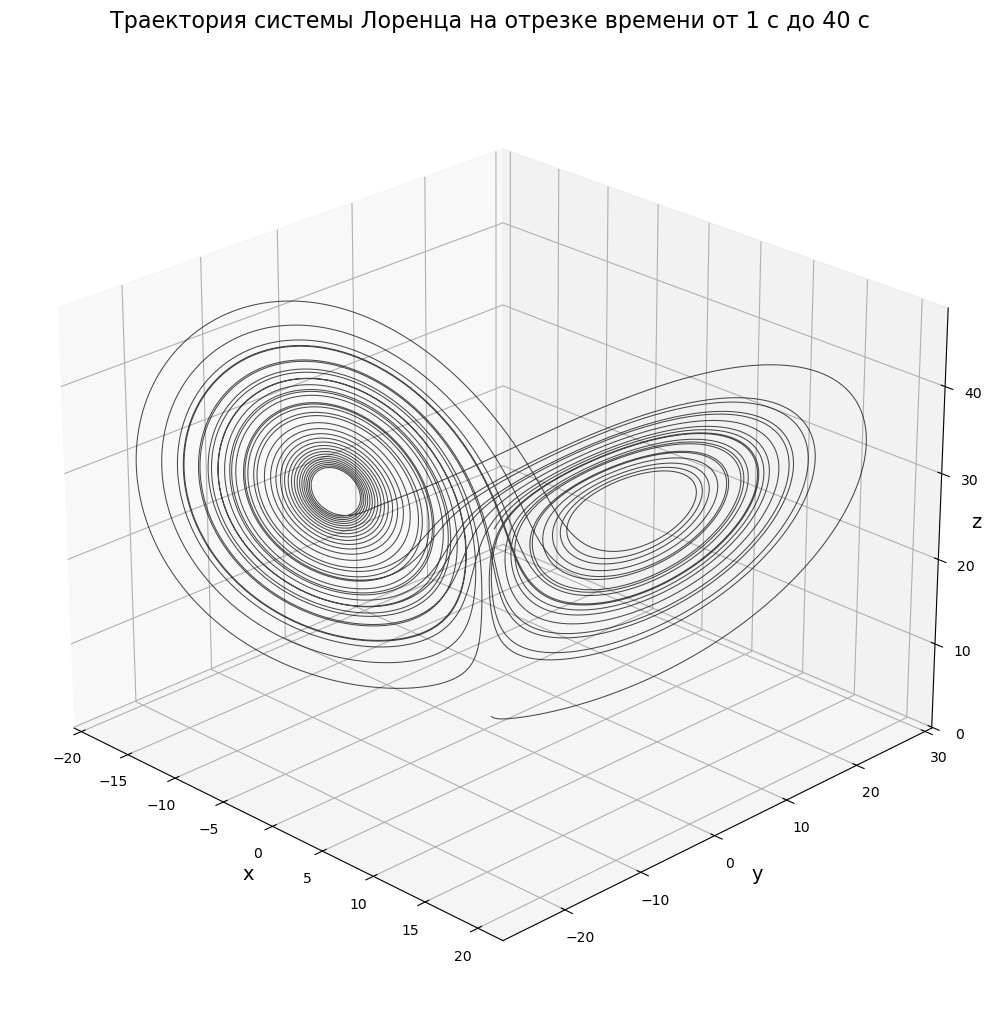

In [21]:
# 1.2. Генерация набора данных

dt = 0.002 # шаг по времени
t = np.arange(1, 40, dt) # дискретизация промежутка времени
t_span = (t[0], t[-1]) # промежуток времени

x0 = [0., 1., 1.05] # начальные условия

# Точное интегрирование
sol = solve_ivp(
    lorenz_ode, 
    t_span, # отрезок по времени
    x0, # начальные условия
    t_eval=t, # массив времени 
    args=(10.0, 28.0, 8/3), # коэффициенты sigma=10.0, rho=28.0, beta=8/3
    rtol=1e-8,  # Относительная точность
    atol=1e-10, # Абсолютная точность
    method='RK45'
)

# Формируем массив данных (n_samples, n_features)
X_train = sol.y.T




# 1.3. Визуализируем данные
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.75, color='black', alpha=0.7)

elev = 25
azim = -45
ax.view_init(elev=elev, azim=azim)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -6)

ax.grid(True, alpha=0.3)
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t[0]:.0f} с до {t[-1]:.0f} с', fontsize=16, pad=20)


plt.subplots_adjust(left=-0.1, right=1.3, bottom=-0.1, top=1.1)

plt.show()

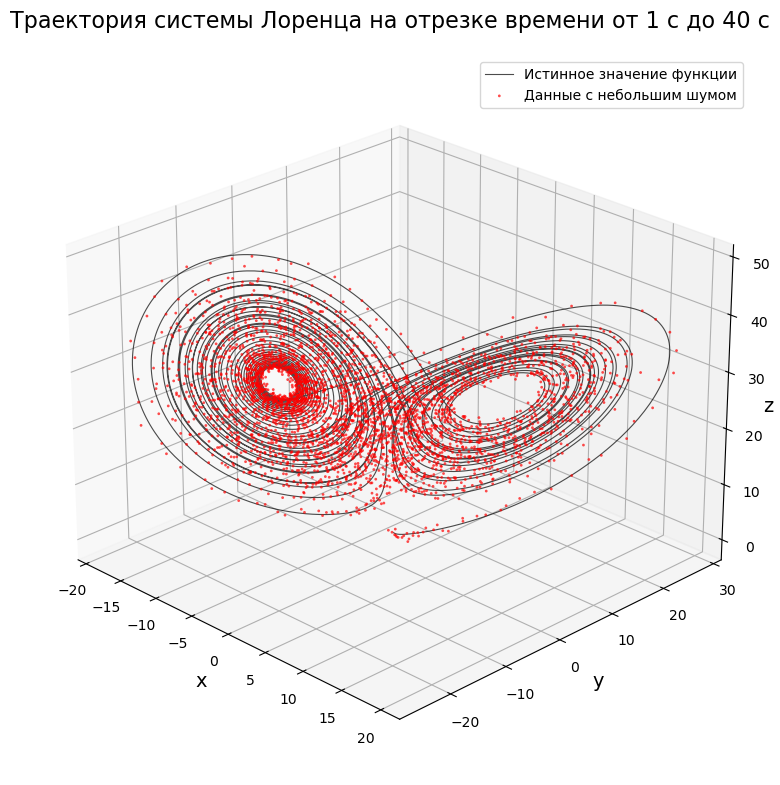

In [22]:
# 1.4. Генерация набора данных с шумом
noise_level = 0.05  # 5% шума относительно std каждой переменной

# Вычисляем std для каждой колонки (x, y, z) отдельно
std_per_feature = np.std(X_train, axis=0)  # массив из 3 значений

# Генерируем шум для каждой переменной
noise = noise_level * std_per_feature * np.random.randn(*X_train.shape)

# Добавляем шум
X_train_noisy = X_train + noise

# 1.5. Визуализируем данные
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Исходная линия
ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.8, color='black', alpha=0.7, label='Истинное значение функции')

# Зашумлённые точки с прозрачностью по плотности
step = 5
ax.scatter(X_train_noisy[:,0][::step],X_train_noisy[:,1][::step], X_train_noisy[:,2][::step], 
           c='red', s=4, alpha=0.7, edgecolors='none', label='Данные с небольшим шумом')

ax.view_init(elev=25, azim=-45)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -4)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t[0]:.0f} с до {t[-1]:.0f} с', fontsize=16, pad=20)
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.05, top=0.95)
plt.show()

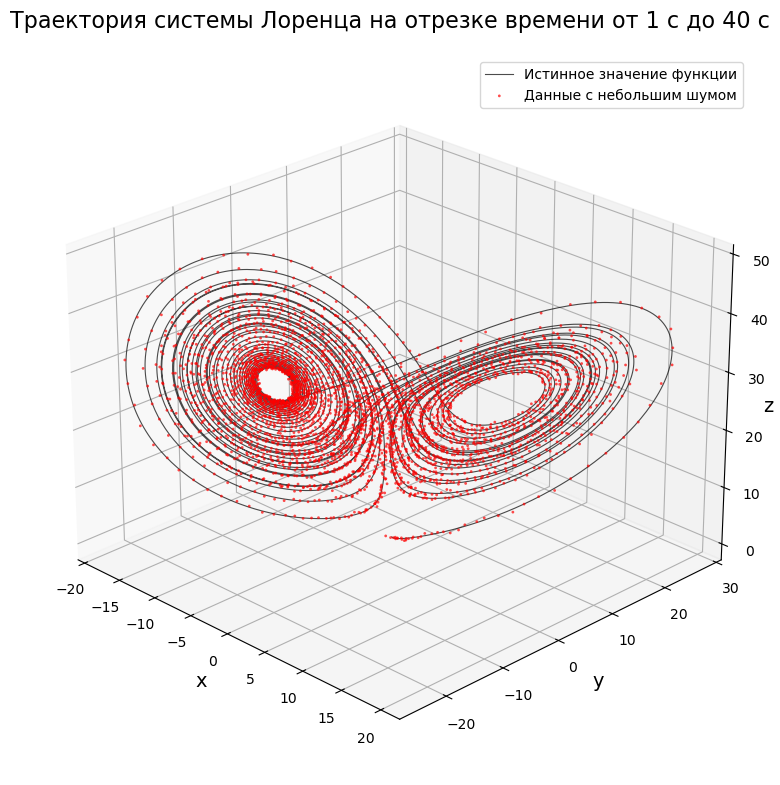

In [23]:
# 1.6. Сгладим зашумленные данные
X_train_smoothed = savgol_filter(X_train_noisy, window_length=15, polyorder=3, axis=0)

# 1.7. Визуализируем данные
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Исходная линия
ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.8, color='black', alpha=0.7, label='Истинное значение функции')

# Зашумлённые точки с прозрачностью по плотности
step = 5
ax.scatter(X_train_smoothed[:,0][::step],X_train_smoothed[:,1][::step], X_train_smoothed[:,2][::step], 
           c='red', s=4, alpha=0.7, edgecolors='none', label='Данные с небольшим шумом')

ax.view_init(elev=25, azim=-45)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -4)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t[0]:.0f} с до {t[-1]:.0f} с', fontsize=16, pad=20)
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.05, top=0.95)
plt.show()

# 2. Базовая задача с ОДУ Лоренца. Поиск коэффициентов уравнения по данным из незашумленныго масива x, y, z, t

In [24]:
# 2.0. Попытка найки коэффициенты уравнения с помощью обыкновенного нормального уравения (threshold=0.0)
feature_names = ['x', 'y', 'z']
opt = ps.STLSQ(threshold=0.0)
model = ps.SINDy(optimizer = opt)
model.fit(X_train, t=t, feature_names = feature_names)
model.print()

(x)' = -10.003 x +  10.002 y
(y)' =  0.010 1 +  27.991 x + -0.998 y + -0.001 z + -1.000 x z
(z)' = -0.010 1 + -0.001 x +  0.001 y + -2.664 z +  0.001 x^2 +  0.999 x y


In [25]:
# 2.1. Вторая попытка найки коэффициенты уравнения (уже с настройкой threshold)
opt = ps.STLSQ(threshold=0.1)
model = ps.SINDy(optimizer = opt)
model.fit(X_train, t=dt, feature_names = feature_names)
model.print()

(x)' = -9.999 x +  9.999 y
(y)' =  27.992 x + -0.998 y + -1.000 x z
(z)' = -2.666 z +  1.000 x y


# 3. Базовая задача с ОДУ Лоренца. Поиск коэффициентов уравнения по зашумленным данным

In [26]:
# 3.0. То же самое, что и 2.1., только с зашумленными данными
opt = ps.STLSQ(threshold=0.1)
model = ps.SINDy(optimizer = opt)
model.fit(X_train_noisy, t=dt, feature_names = feature_names)
model.print()

(x)' =  0.158 1 + -9.764 x +  9.786 y
(y)' = -0.182 1 +  27.111 x + -0.735 y + -0.979 x z
(z)' = -0.199 1 + -2.650 z +  0.995 x y


In [27]:
# 3.1. Попробуем более тонко настроить вид функции, в частности возьмем полином и отключим у него свободный член
opt = ps.STLSQ(threshold=0.1, alpha=0.01, normalize_columns=False)
model = ps.SINDy(optimizer = opt, feature_library = ps.PolynomialLibrary(degree=2, include_bias=False))
model.fit(X_train_noisy, t=dt, feature_names = feature_names)
model.print()

(x)' = -9.769 x +  9.786 y
(y)' =  27.138 x + -0.741 y + -0.980 x z
(z)' = -2.657 z +  0.995 x y


# 4. Автоматический поиск коэффициентов уравнения.
## 4.0. Незашумленные данные

In [28]:
# 4.0.0. Функция для перебора threshold
def tune_sindy_threshold(X_train, t, threshold_scan, feature_names, degree=2):
    """
    Автоматический подбор параметра threshold для оптимизатора STLSQ в PySINDy.
    
    Параметры:
    ----------
    X_train : array-like of shape (n_samples, n_features)
        Матрица состояний системы.
    dt : float
        Шаг интегрирования/дискретизации по времени.
    threshold_scan : array-like, optional
        Массив значений threshold для перебора. По умолчанию: np.arange(0.01, 0.5, 0.01)
    feature_names : list of str, optional
        Имена переменных. По умолчанию: ['x', 'y', 'z']
    degree : int, optional
        Степень полиномиальной библиотеки. По умолчанию: 2
            
    Возвращает:
    -----------
    dict : {'best_model', 'best_threshold', 'best_idx', 'mse_scores', 'r2_scores', 'threshold_scan'}
    """

    mse_scores = np.zeros(len(threshold_scan))
    r2_scores = np.zeros(len(threshold_scan))
    best_idx = 0
    min_mse = np.inf
    best_model = None

    # Вычисляем производные один раз для всех итераций
    sfd = SmoothedFiniteDifference(smoother_kws={'window_length': 5})
    X_dot_true = sfd._differentiate(X_train, t)
    
  
    # Подавляем предупреждения PySINDy только внутри цикла
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        
        for i, thr in enumerate(threshold_scan):
            opt = ps.STLSQ(threshold=thr, max_iter=100, normalize_columns=False)
            model = ps.SINDy(
                optimizer=opt,
                feature_library=ps.PolynomialLibrary(degree=degree, include_bias=False)
            )
            
            model.fit(X_train, t=t, x_dot=X_dot_true, feature_names=feature_names)
            
            X_dot_pred = model.predict(X_train)
            mse_scores[i] = mean_squared_error(X_dot_true, X_dot_pred, multioutput='uniform_average')
            r2_scores[i] = r2_score(X_dot_true, X_dot_pred, multioutput='uniform_average')
            
            if mse_scores[i] < min_mse:
                min_mse = mse_scores[i]
                best_idx = i
                best_model = model

    best_threshold = threshold_scan[best_idx]

    return {
        'best_model': best_model,
        'best_threshold': best_threshold,
        'best_idx': best_idx,
        'mse_scores': mse_scores,
        'r2_scores': r2_scores,
        'threshold_scan': threshold_scan
    }

# 4.0.0. Пробуем с незашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train, t, 
                               threshold_scan = np.arange (0.01, 0.5, 0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
best_model = results['best_model']
best_thr   = results['best_threshold']
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
best_idx   = results['best_idx']

print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()


Лучший threshold: 0.0100
Средняя абсолютная ошибка: 0.0001
Коэффициент детерминации: 1.0000
Модель:
(x)' = -9.999 x +  9.999 y
(y)' =  27.992 x + -0.998 y + -1.000 x z
(z)' = -2.666 z +  1.000 x y


## 4.1. Зашумленные данные

In [29]:
# 4.1.0. Пробуем с зашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train_noisy, t, 
                               threshold_scan = np.arange (0.2, 0.5, 0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
best_model = results['best_model']
best_thr   = results['best_threshold']
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
best_idx   = results['best_idx']

print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()

Лучший threshold: 0.2000
Средняя абсолютная ошибка: 9340.3837
Коэффициент детерминации: 0.2529
Модель:
(x)' = -9.754 x +  9.772 y
(y)' =  25.408 x + -0.946 x z
(z)' = -2.658 z +  0.996 x y


## 4.2. Сглаженные данные

In [30]:
# 4.2.0. Пробуем с зашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train_smoothed, t, 
                               threshold_scan = np.arange (0.1, 0.5, 0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
best_model = results['best_model']
best_thr   = results['best_threshold']
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
best_idx   = results['best_idx']

print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()

Лучший threshold: 0.1000
Средняя абсолютная ошибка: 607.1902
Коэффициент детерминации: 0.8204
Модель:
(x)' = -9.955 x +  9.954 y
(y)' =  27.867 x + -0.968 y + -0.997 x z
(z)' = -2.668 z +  1.000 x y
